In [36]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg


In [37]:
# Define the ranges for input variables
size = ctrl.Antecedent(np.arange(0, 51, 1), 'size')
gender = ctrl.Antecedent(np.arange(0, 2, 1), 'gender')
style = ctrl.Antecedent(np.arange(0, 11, 1), 'style')
formality_occasion = ctrl.Antecedent(np.arange(0, 11, 1), 'formality_occasion')

c:\Users\MO_KH\anaconda3\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


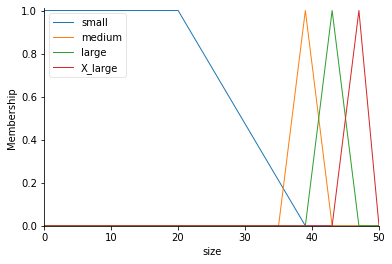

In [38]:
size['small'] = fuzz.trapmf(size.universe, [0, 0, 20, 39])
size['medium'] = fuzz.trimf(size.universe, [35, 39, 43])
size['large'] = fuzz.trimf(size.universe, [39, 43, 47])
size['X_large'] = fuzz.trimf(size.universe, [43, 47, 50])
size.view()

c:\Users\MO_KH\anaconda3\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


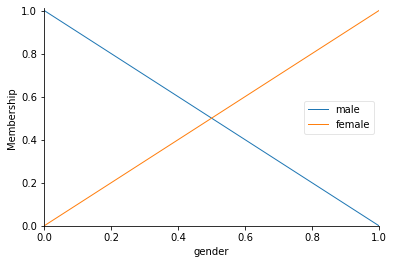

In [39]:
gender['male'] = fuzz.trimf(gender.universe, [0, 0, 1])
gender['female'] = fuzz.trimf(gender.universe, [1, 1, 2])
gender.view()

c:\Users\MO_KH\anaconda3\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


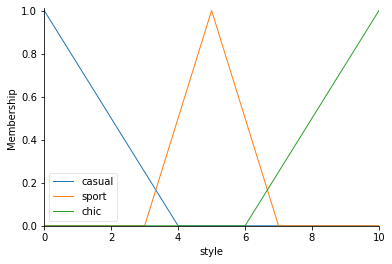

In [40]:
style['casual'] = fuzz.trimf(style.universe, [0, 0, 4])
style['sport'] = fuzz.trimf(style.universe, [3, 5, 7])
style['chic'] = fuzz.trimf(style.universe, [6, 10, 10])
style.view()

c:\Users\MO_KH\anaconda3\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


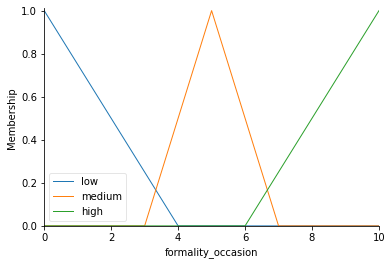

In [41]:
formality_occasion['low'] = fuzz.trimf(formality_occasion.universe, [0, 0, 4])
formality_occasion['medium'] = fuzz.trimf(formality_occasion.universe, [3, 5, 7])
formality_occasion['high'] = fuzz.trimf(formality_occasion.universe, [6, 10, 10])
formality_occasion.view()

In [42]:
outfit = ctrl.Consequent(np.arange(0, 92, 1), 'outfit', defuzzify_method='bisector')

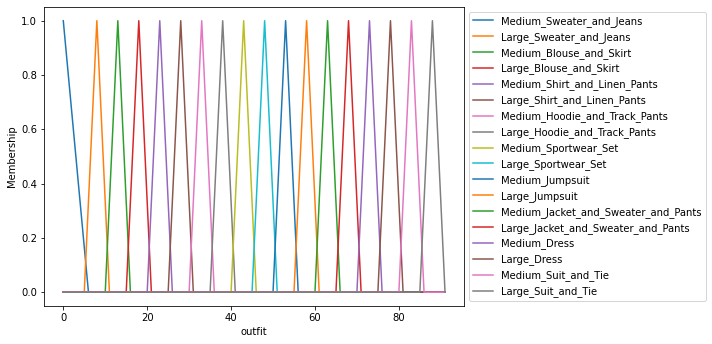

In [43]:
outfit['Medium_Sweater_and_Jeans'] = fuzz.trimf(outfit.universe, [0, 0, 6])
outfit['Large_Sweater_and_Jeans'] = fuzz.trimf(outfit.universe, [5, 8, 11])
outfit['Medium_Blouse_and_Skirt'] = fuzz.trimf(outfit.universe, [10, 13, 16])
outfit['Large_Blouse_and_Skirt'] = fuzz.trimf(outfit.universe, [15, 18, 21])
outfit['Medium_Shirt_and_Linen_Pants'] = fuzz.trimf(outfit.universe, [20, 23, 26])
outfit['Large_Shirt_and_Linen_Pants'] = fuzz.trimf(outfit.universe, [25, 28, 31])
outfit['Medium_Hoodie_and_Track_Pants'] = fuzz.trimf(outfit.universe, [30, 33, 36])
outfit['Large_Hoodie_and_Track_Pants'] = fuzz.trimf(outfit.universe, [35, 38, 41])
outfit['Medium_Sportwear_Set'] = fuzz.trimf(outfit.universe, [40, 43, 46])
outfit['Large_Sportwear_Set'] = fuzz.trimf(outfit.universe, [45, 48, 51])
outfit['Medium_Jumpsuit'] = fuzz.trimf(outfit.universe, [50, 53, 56])
outfit['Large_Jumpsuit'] = fuzz.trimf(outfit.universe, [55, 58, 61])
outfit['Medium_Jacket_and_Sweater_and_Pants'] = fuzz.trimf(outfit.universe, [60, 63, 66])
outfit['Large_Jacket_and_Sweater_and_Pants'] = fuzz.trimf(outfit.universe, [65, 68, 71])
outfit['Medium_Dress'] = fuzz.trimf(outfit.universe, [70, 73, 76])
outfit['Large_Dress'] = fuzz.trimf(outfit.universe, [75, 78, 81])
outfit['Medium_Suit_and_Tie'] = fuzz.trimf(outfit.universe, [80, 83, 86])
outfit['Large_Suit_and_Tie'] = fuzz.trimf(outfit.universe, [85, 88, 91])

fig, ax = plt.subplots(figsize=(10, 5))
for label, func in outfit.terms.items():
    ax.plot(outfit.universe, func.mf, label=label)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel('outfit')
ax.set_ylabel('Membership')
plt.tight_layout()
plt.show()


In [44]:
# Define rules
rule1 = ctrl.Rule(size['small']  & (gender['male'] | gender['female']) & style['casual'] & formality_occasion['low'], outfit['Medium_Sweater_and_Jeans'])
rule2 = ctrl.Rule(size['small']  & gender['male'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Medium_Shirt_and_Linen_Pants'])
rule3 = ctrl.Rule(size['small']  & gender['female'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Medium_Blouse_and_Skirt'])
rule4 = ctrl.Rule(size['small']  & (gender['male'] | gender['female']) & style['sport'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Medium_Hoodie_and_Track_Pants'])
rule5 = ctrl.Rule(size['small']  & (gender['male'] | gender['female']) & style['sport'] & formality_occasion['high'], outfit['Medium_Sportwear_Set'])
rule6 = ctrl.Rule(size['small']  & gender['male'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Medium_Jacket_and_Sweater_and_Pants'])
rule7 = ctrl.Rule(size['small']  & gender['female'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Medium_Jumpsuit'])
rule8 = ctrl.Rule(size['small']  & gender['male'] & style['chic'] & formality_occasion['high'], outfit['Medium_Suit_and_Tie'])
rule9 = ctrl.Rule(size['small']  & gender['female'] & style['chic'] & formality_occasion['high'], outfit['Medium_Dress'])
#___________________________
rule10 = ctrl.Rule(size['medium']  & (gender['male'] | gender['female']) & style['casual'] & formality_occasion['low'], outfit['Medium_Sweater_and_Jeans'])
rule11 = ctrl.Rule(size['medium']  & gender['male'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Medium_Shirt_and_Linen_Pants'])
rule12 = ctrl.Rule(size['medium']  & gender['female'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Medium_Blouse_and_Skirt'])
rule13 = ctrl.Rule(size['medium']  & (gender['male'] | gender['female']) & style['sport'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Medium_Hoodie_and_Track_Pants'])
rule14 = ctrl.Rule(size['medium']  & (gender['male'] | gender['female']) & style['sport'] & formality_occasion['high'], outfit['Medium_Sportwear_Set'])
rule15 = ctrl.Rule(size['medium']  & gender['male'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Medium_Jacket_and_Sweater_and_Pants'])
rule16 = ctrl.Rule(size['medium']  & gender['female'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Medium_Jumpsuit'])
rule17 = ctrl.Rule(size['medium']  & gender['male'] & style['chic'] & formality_occasion['high'], outfit['Medium_Suit_and_Tie'])
rule18 = ctrl.Rule(size['medium']  & gender['female'] & style['chic'] & formality_occasion['high'], outfit['Medium_Dress'])
#___________________________
rule19 = ctrl.Rule(size['large']  & (gender['male'] | gender['female']) & style['casual'] & formality_occasion['low'], outfit['Large_Sweater_and_Jeans'])
rule20 = ctrl.Rule(size['large']  & gender['male'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Large_Shirt_and_Linen_Pants'])
rule21 = ctrl.Rule(size['large']  & gender['female'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Large_Blouse_and_Skirt'])
rule22 = ctrl.Rule(size['large']  & (gender['male'] | gender['female']) & style['sport'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Large_Hoodie_and_Track_Pants'])
rule23 = ctrl.Rule(size['large']  & (gender['male'] | gender['female']) & style['sport'] & formality_occasion['high'], outfit['Large_Sportwear_Set'])
rule24 = ctrl.Rule(size['large']  & gender['male'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Large_Jacket_and_Sweater_and_Pants'])
rule25 = ctrl.Rule(size['large']  & gender['female'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Large_Jumpsuit'])
rule26 = ctrl.Rule(size['large']  & gender['male'] & style['chic'] & formality_occasion['high'], outfit['Large_Suit_and_Tie'])
rule27 = ctrl.Rule(size['large']  & gender['female'] & style['chic'] & formality_occasion['high'], outfit['Large_Dress'])
#___________________________
rule28 = ctrl.Rule(size['X_large']  & (gender['male'] | gender['female']) & style['casual'] & formality_occasion['low'], outfit['Large_Sweater_and_Jeans'])
rule29 = ctrl.Rule(size['X_large']  & gender['male'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Large_Shirt_and_Linen_Pants'])
rule30 = ctrl.Rule(size['X_large']  & gender['female'] & style['casual'] & (formality_occasion['medium'] | formality_occasion['high']), outfit['Large_Blouse_and_Skirt'])
rule31 = ctrl.Rule(size['X_large']  & (gender['male'] | gender['female']) & style['sport'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Large_Hoodie_and_Track_Pants'])
rule32 = ctrl.Rule(size['X_large']  & (gender['male'] | gender['female']) & style['sport'] & formality_occasion['high'], outfit['Large_Sportwear_Set'])
rule33 = ctrl.Rule(size['X_large']  & gender['male'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Large_Jacket_and_Sweater_and_Pants'])
rule34 = ctrl.Rule(size['X_large']  & gender['female'] & style['chic'] & (formality_occasion['low'] | formality_occasion['medium']), outfit['Large_Jumpsuit'])
rule35 = ctrl.Rule(size['X_large']  & gender['male'] & style['chic'] & formality_occasion['high'], outfit['Large_Suit_and_Tie'])
rule36 = ctrl.Rule(size['X_large']  & gender['female'] & style['chic'] & formality_occasion['high'], outfit['Large_Dress'])

In [45]:
rules_list = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
              rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20,
              rule21, rule22, rule23, rule24, rule25, rule26, rule27, rule28, rule29, rule30,
              rule31, rule32, rule33, rule34, rule35, rule36]

# for rule in rules_list:
#     rule.view()


In [46]:
outfit

Consequent: outfit

In [47]:
# Create control system and simulation
outfit_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9,
                                  rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
                                  rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27,
                                  rule28, rule29, rule30, rule31, rule32, rule33, rule34, rule35, rule36])
outfit_simulation = ctrl.ControlSystemSimulation(outfit_ctrl)

33.0
Recommended Outfit: Medium_Hoodie_and_Track_Pants


c:\Users\MO_KH\anaconda3\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


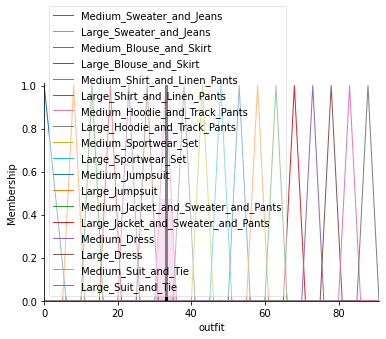

In [48]:
# Example input and output
outfit_simulation.input['size'] = 30
outfit_simulation.input['gender'] = 0
outfit_simulation.input['style'] = 5
outfit_simulation.input['formality_occasion'] = 0
outfit_simulation.compute()
print(outfit_simulation.output['outfit'])
# Determine the output category
output_value = outfit_simulation.output['outfit']
output_membership = {
    'Medium_Sweater_and_Jeans': fuzz.interp_membership(outfit.universe, outfit['Medium_Sweater_and_Jeans'].mf, output_value),
    'Medium_Blouse_and_Skirt': fuzz.interp_membership(outfit.universe, outfit['Medium_Blouse_and_Skirt'].mf, output_value),
    'Medium_Shirt_and_Linen_Pants': fuzz.interp_membership(outfit.universe, outfit['Medium_Shirt_and_Linen_Pants'].mf, output_value),
    'Medium_Hoodie_and_Track_Pants': fuzz.interp_membership(outfit.universe, outfit['Medium_Hoodie_and_Track_Pants'].mf, output_value),
    'Medium_Sportwear_Set': fuzz.interp_membership(outfit.universe, outfit['Medium_Sportwear_Set'].mf, output_value),
    'Medium_Jumpsuit': fuzz.interp_membership(outfit.universe, outfit['Medium_Jumpsuit'].mf, output_value),
    'Medium_Jacket_and_Sweater_and_Pants': fuzz.interp_membership(outfit.universe, outfit['Medium_Jacket_and_Sweater_and_Pants'].mf, output_value),
    'Medium_Dress': fuzz.interp_membership(outfit.universe, outfit['Medium_Dress'].mf, output_value),
    'Medium_Suit_and_Tie': fuzz.interp_membership(outfit.universe, outfit['Medium_Suit_and_Tie'].mf, output_value),
    'Large_Sweater_and_Jeans': fuzz.interp_membership(outfit.universe, outfit['Large_Sweater_and_Jeans'].mf, output_value),
    'Large_Blouse_and_Skirt': fuzz.interp_membership(outfit.universe, outfit['Large_Blouse_and_Skirt'].mf, output_value),
    'Large_Shirt_and_Linen_Pants': fuzz.interp_membership(outfit.universe, outfit['Large_Shirt_and_Linen_Pants'].mf, output_value),
    'Large_Hoodie_and_Track_Pants': fuzz.interp_membership(outfit.universe, outfit['Large_Hoodie_and_Track_Pants'].mf, output_value),
    'Large_Sportwear_Set': fuzz.interp_membership(outfit.universe, outfit['Large_Sportwear_Set'].mf, output_value),
    'Large_Jumpsuit': fuzz.interp_membership(outfit.universe, outfit['Large_Jumpsuit'].mf, output_value),
    'Large_Jacket_and_Sweater_and_Pants': fuzz.interp_membership(outfit.universe, outfit['Large_Jacket_and_Sweater_and_Pants'].mf, output_value),
    'Large_Dress': fuzz.interp_membership(outfit.universe, outfit['Large_Dress'].mf, output_value),
    'Large_Suit_and_Tie': fuzz.interp_membership(outfit.universe, outfit['Large_Suit_and_Tie'].mf, output_value)
   
}

# Find the category with the highest membership value
max_membership_category = max(output_membership, key=output_membership.get)
print(f"Recommended Outfit: {max_membership_category}")

outfit.view(sim= outfit_simulation)

# User Interface

In [49]:
def evaluate_outfit():
    size_val = float(size_entry.get())
    gender_val = gender_var.get()
    style_val = float(style_entry.get())
    formality_val = float(formality_entry.get())
    
    outfit_simulation.input['size'] = size_val
    outfit_simulation.input['gender'] = gender_val
    outfit_simulation.input['style'] = style_val
    outfit_simulation.input['formality_occasion'] = formality_val
    outfit_simulation.compute()
    
    output_value = outfit_simulation.output['outfit']

    output_membership = {
        'Medium_Sweater_and_Jeans': fuzz.interp_membership(outfit.universe, outfit['Medium_Sweater_and_Jeans'].mf, output_value),
        'Medium_Blouse_and_Skirt': fuzz.interp_membership(outfit.universe, outfit['Medium_Blouse_and_Skirt'].mf, output_value),
        'Medium_Shirt_and_Linen_Pants': fuzz.interp_membership(outfit.universe, outfit['Medium_Shirt_and_Linen_Pants'].mf, output_value),
        'Medium_Hoodie_and_Track_Pants': fuzz.interp_membership(outfit.universe, outfit['Medium_Hoodie_and_Track_Pants'].mf, output_value),
        'Medium_Sportwear_Set': fuzz.interp_membership(outfit.universe, outfit['Medium_Sportwear_Set'].mf, output_value),
        'Medium_Jumpsuit': fuzz.interp_membership(outfit.universe, outfit['Medium_Jumpsuit'].mf, output_value),
        'Medium_Jacket_and_Sweater_and_Pants': fuzz.interp_membership(outfit.universe, outfit['Medium_Jacket_and_Sweater_and_Pants'].mf, output_value),
        'Medium_Dress': fuzz.interp_membership(outfit.universe, outfit['Medium_Dress'].mf, output_value),
        'Medium_Suit_and_Tie': fuzz.interp_membership(outfit.universe, outfit['Medium_Suit_and_Tie'].mf, output_value),
        'Large_Sweater_and_Jeans': fuzz.interp_membership(outfit.universe, outfit['Large_Sweater_and_Jeans'].mf, output_value),
        'Large_Blouse_and_Skirt': fuzz.interp_membership(outfit.universe, outfit['Large_Blouse_and_Skirt'].mf, output_value),
        'Large_Shirt_and_Linen_Pants': fuzz.interp_membership(outfit.universe, outfit['Large_Shirt_and_Linen_Pants'].mf, output_value),
        'Large_Hoodie_and_Track_Pants': fuzz.interp_membership(outfit.universe, outfit['Large_Hoodie_and_Track_Pants'].mf, output_value),
        'Large_Sportwear_Set': fuzz.interp_membership(outfit.universe, outfit['Large_Sportwear_Set'].mf, output_value),
        'Large_Jumpsuit': fuzz.interp_membership(outfit.universe, outfit['Large_Jumpsuit'].mf, output_value),
        'Large_Jacket_and_Sweater_and_Pants': fuzz.interp_membership(outfit.universe, outfit['Large_Jacket_and_Sweater_and_Pants'].mf, output_value),
        'Large_Dress': fuzz.interp_membership(outfit.universe, outfit['Large_Dress'].mf, output_value),
        'Large_Suit_and_Tie': fuzz.interp_membership(outfit.universe, outfit['Large_Suit_and_Tie'].mf, output_value)
    }

    max_membership_category = max(output_membership, key=output_membership.get)
    result_label.config(text=f"Recommended Outfit: {max_membership_category}") 
    output_value_label.config(text=f"Output Value: {output_value}")  
     
    show_inference_plot(size_val, style_val, formality_val, output_value)

In [50]:
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure

def show_inference_plot(size_val, style_val, formality_val, output_value):
    # Create a new Tkinter window for each plot
    size_window = tk.Toplevel()
    size_window.title("Size Membership")
    size_fig = Figure(figsize=(8, 6))
    size_plot = size_fig.add_subplot(111)
    size_plot.plot(size.universe, fuzz.trapmf(size.universe, [0, 0, 20, 39]), label='Small')
    size_plot.plot(size.universe, fuzz.trimf(size.universe, [35, 39, 43]), label='Medium')
    size_plot.plot(size.universe, fuzz.trimf(size.universe, [39, 43, 47]), label='Large')
    size_plot.plot(size.universe, fuzz.trimf(size.universe, [43, 47, 50]), label='X-Large')
    size_plot.axvline(x=size_val, color='r', linestyle='--', label='Input Size')
    size_plot.legend()
    size_plot.set_xlabel('Size')
    size_plot.set_ylabel('Membership')
    size_canvas = FigureCanvasTkAgg(size_fig, master=size_window)
    size_canvas.draw()
    size_canvas.get_tk_widget().pack()

    style_window = tk.Toplevel()
    style_window.title("Style Membership")
    style_fig = Figure(figsize=(8, 6))
    style_plot = style_fig.add_subplot(111)
    style_plot.plot(style.universe, fuzz.trimf(style.universe, [0, 0, 4]), label='Casual')
    style_plot.plot(style.universe, fuzz.trimf(style.universe, [3, 5, 7]), label='Sport')
    style_plot.plot(style.universe, fuzz.trimf(style.universe, [6, 10, 10]), label='Chic')
    style_plot.axvline(x=style_val, color='g', linestyle='--', label='Input Style')
    style_plot.legend()
    style_plot.set_xlabel('Style')
    style_plot.set_ylabel('Membership')
    style_canvas = FigureCanvasTkAgg(style_fig, master=style_window)
    style_canvas.draw()
    style_canvas.get_tk_widget().pack()

    formality_window = tk.Toplevel()
    formality_window.title("Formality Occasion Membership")
    formality_fig = Figure(figsize=(8, 6))
    formality_plot = formality_fig.add_subplot(111)
    formality_plot.plot(formality_occasion.universe, fuzz.trimf(formality_occasion.universe, [0, 0, 4]), label='Low Formality')
    formality_plot.plot(formality_occasion.universe, fuzz.trimf(formality_occasion.universe, [3, 5, 7]), label='Medium Formality')
    formality_plot.plot(formality_occasion.universe, fuzz.trimf(formality_occasion.universe, [6, 10, 10]), label='High Formality')
    formality_plot.axvline(x=formality_val, color='b', linestyle='--', label='Input Formality')
    formality_plot.legend()
    formality_plot.set_xlabel('Formality Occasion')
    formality_plot.set_ylabel('Membership')
    formality_canvas = FigureCanvasTkAgg(formality_fig, master=formality_window)
    formality_canvas.draw()
    formality_canvas.get_tk_widget().pack()

    aggregated_output_window = tk.Toplevel()
    aggregated_output_window.title("Aggregated Output")
    output_value = outfit_simulation.output['outfit']
    aggregated_output_fig = Figure(figsize=(8, 6))
    aggregated_output_canvas = FigureCanvasTkAgg(aggregated_output_fig, master=aggregated_output_window)
    outfit.view(sim=outfit_simulation)
    aggregated_output_canvas.draw()
    aggregated_output_canvas.get_tk_widget().pack()

    defuzzified_output_window = tk.Toplevel()
    defuzzified_output_window.title("Defuzzified Output")
    defuzzified_output_fig = Figure(figsize=(8, 6))
    defuzzified_output_plot = defuzzified_output_fig.add_subplot(111)
    defuzzified_output_plot.plot(outfit.universe, fuzz.trimf(outfit.universe, [output_value, output_value, output_value]), 'r', linewidth=2, label='Aggregated Output')
    defuzzified_output_plot.axvline(x=output_value, color='k', linestyle='--', label='Defuzzified Output')
    defuzzified_output_plot.legend()
    defuzzified_output_plot.set_xlabel('Outfit')
    defuzzified_output_plot.set_ylabel('Membership')
    defuzzified_output_canvas = FigureCanvasTkAgg(defuzzified_output_fig, master=defuzzified_output_window)
    defuzzified_output_canvas.draw()
    defuzzified_output_canvas.get_tk_widget().pack()

    # Show the Tkinter windows
    size_window.mainloop()
    style_window.mainloop()
    formality_window.mainloop()
    aggregated_output_window.mainloop()
    defuzzified_output_window.mainloop()


c:\Users\MO_KH\anaconda3\lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


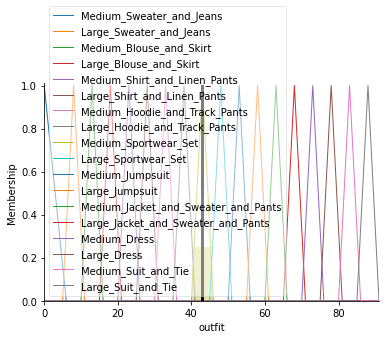

In [51]:
# GUI setup
root = tk.Tk()
root.title("Fuzzy Outfit Recommender")
root.geometry("850x550")  # Increased height to accommodate the plot
font_large = ("Helvetica", 14)

tk.Label(root, text="Size (0-50):", font=font_large).grid(row=0, column=0, padx=10, pady=10)
size_entry = tk.Entry(root, font=font_large)
size_entry.grid(row=0, column=1, padx=10, pady=10)

tk.Label(root, text="Gender:", font=font_large).grid(row=1, column=0, padx=10, pady=10)
gender_var = tk.IntVar()
tk.Radiobutton(root, text="Male", variable=gender_var, value=0, font=font_large).grid(row=1, column=1, padx=10, pady=10)
tk.Radiobutton(root, text="Female", variable=gender_var, value=1, font=font_large).grid(row=1, column=2, padx=10, pady=10)

tk.Label(root, text="Style [casual(0-4),sport(3-7),chic(6-10)]:", font=font_large).grid(row=2, column=0, padx=10, pady=10)
style_entry = tk.Entry(root, font=font_large)
style_entry.grid(row=2, column=1, padx=10, pady=10)

tk.Label(root, text="Formality Occasion (0-10):", font=font_large).grid(row=3, column=0, padx=10, pady=10)
formality_entry = tk.Entry(root, font=font_large)
formality_entry.grid(row=3, column=1, padx=10, pady=10)

tk.Button(root, text="Evaluate", command=evaluate_outfit, font=font_large, bg="green", fg="white").grid(row=5, column=0, columnspan=2, pady=20)

# Define result_label and output_value_label
result_label = tk.Label(root, text="Recommended Outfit: ", font=font_large)
result_label.grid(row=6, column=0, columnspan=2, pady=10)

output_value_label = tk.Label(root, text="Output Value: ", font=font_large)
output_value_label.grid(row=7, column=0, columnspan=2, pady=10)


root.mainloop()

In [52]:
import random

# تعريف المجالات لكل فئة
size_range = {
    'small': (0, 39),
    'medium': (35, 43),
    'large': (39, 47),
    'X_large': (43, 50)
}

gender_range = {
    'male': (0, 0),
    'female': (1, 1)
}

style_range = {
    'casual': (0, 4),
    'sport': (3, 7),
    'chic': (6, 10)
}

formality_occasion_range = {
    'low': (0, 4),
    'medium': (3, 7),
    'high': (6, 10)
}

# الدالة لتحويل صف واحد من البيانات
def convert_row_to_random_values(row):
    size = random.randint(*size_range[row['size']])
    gender = random.randint(*gender_range[row['gender']])
    style = random.randint(*style_range[row['style']])
    formality_occasion = random.randint(*formality_occasion_range[row['formality_occasion']])
    
    return {
        'size': size,
        'gender': gender,
        'style': style,
        'formality_occasion': formality_occasion
    }

# مثال على مجموعة من البيانات
dataset = [
    {'size': 'medium', 'gender': 'female', 'style': 'chic', 'formality_occasion': 'high'},
    {'size': 'small', 'gender': 'male', 'style': 'casual', 'formality_occasion': 'low'},
    # إضافة صفوف أخرى حسب الحاجة
]

# تحويل مجموعة البيانات بأكملها
converted_dataset = [convert_row_to_random_values(row) for row in dataset]

# طباعة النتيجة
print(converted_dataset)


[{'size': 35, 'gender': 1, 'style': 7, 'formality_occasion': 6}, {'size': 16, 'gender': 0, 'style': 4, 'formality_occasion': 0}]


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('Data/fuzzy_dataset.csv')
df = pd.DataFrame(df)
df.head(72)

,size,gender,style,formality_occasion,outfit
0,small,male,casual,low,Medium_Sweater_and_Jeans
1,small,male,casual,medium,Medium_Shirt_and_Linen_Pants
2,small,female,casual,high,Medium_Blouse_and_Skirt
3,small,female,sport,low,Medium_Hoodie_and_Track_Pants
4,small,male,sport,high,Medium_Sportwear_Set
...,...,...,...,...,...
67,X_large,female,sport,high,Large_Sportwear_Set
68,X_large,male,chic,medium,Large_Jacket_and_Sweater_and_Pants
69,X_large,female,chic,medium,Large_Jumpsuit
70,X_large,male,chic,high,Large_Suit_and_Tie


In [54]:
# تعريف المجالات لكل فئة
size_range = {
    'small': (0, 39),
    'medium': (35, 43),
    'large': (39, 47),
    'X_large': (43, 50)
}

gender_range = {
    'male': (0, 0),
    'female': (1, 1)
}

style_range = {
    'casual': (0, 4),
    'sport': (3, 7),
    'chic': (6, 10)
}

formality_occasion_range = {
    'low': (0, 4),
    'medium': (3, 7),
    'high': (6, 10)
}

In [55]:
# الدالة لتحويل صف واحد من البيانات
def convert_row_to_random_values(row):
    size = random.randint(*size_range[row['size']])
    gender = random.randint(*gender_range[row['gender']])
    style = random.randint(*style_range[row['style']])
    formality_occasion = random.randint(*formality_occasion_range[row['formality_occasion']])
    
    return {
        'size': size,
        'gender': gender,
        'style': style,
        'formality_occasion': formality_occasion
    }

In [56]:
# تحويل مجموعة البيانات بأكملها
converted_dataset = [convert_row_to_random_values(row) for row in df.iterrows()]

print(converted_dataset)

TypeError: tuple indices must be integers or slices, not str

In [ ]:
import pandas as pd
import random

# قراءة البيانات من ملف CSV
df = pd.read_csv('Data/fuzzy_dataset.csv')

# تعريف المجالات لكل فئة
size_range = {
    'small': (0, 39),
    'medium': (35, 43),
    'large': (39, 47),
    'X_large': (43, 50)
}

gender_range = {
    'male': (0, 0),
    'female': (1, 1)
}

style_range = {
    'casual': (0, 4),
    'sport': (3, 7),
    'chic': (6, 10)
}

formality_occasion_range = {
    'low': (0, 4),
    'medium': (3, 7),
    'high': (6, 10)
}

# الدالة لتحويل صف واحد من البيانات
def convert_row_to_random_values(row):
    size = random.randint(*size_range[row['size']])
    gender = random.randint(*gender_range[row['gender']])
    style = random.randint(*style_range[row['style']])
    formality_occasion = random.randint(*formality_occasion_range[row['formality_occasion']])
    
    return {
        'size': size,
        'gender': gender,
        'style': style,
        'formality_occasion': formality_occasion
    }

# تحويل مجموعة البيانات بأكملها
converted_dataset = [convert_row_to_random_values(row) for index, row in df.iterrows()]

# تحويل القائمة إلى DataFrame
converted_df = pd.DataFrame(converted_dataset)

# عرض النتيجة
print(converted_df.head(72))


    size  gender  style  formality_occasion
0     14       0      1                   0
1     18       0      4                   4
2      9       1      0                   7
3      3       1      7                   0
4     32       0      4                   8
..   ...     ...    ...                 ...
67    48       1      5                  10
68    44       0      7                   5
69    49       1      7                   3
70    43       0      8                   9
71    48       1     10                  10

[72 rows x 4 columns]


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('Data/fuzzy_dataset.csv')
df.head(72)

,size,gender,style,formality_occasion,outfit
0,small,male,casual,low,Medium_Sweater_and_Jeans
1,small,male,casual,medium,Medium_Shirt_and_Linen_Pants
2,small,female,casual,high,Medium_Blouse_and_Skirt
3,small,female,sport,low,Medium_Hoodie_and_Track_Pants
4,small,male,sport,high,Medium_Sportwear_Set
...,...,...,...,...,...
67,X_large,female,sport,high,Large_Sportwear_Set
68,X_large,male,chic,medium,Large_Jacket_and_Sweater_and_Pants
69,X_large,female,chic,medium,Large_Jumpsuit
70,X_large,male,chic,high,Large_Suit_and_Tie


In [ ]:

# Load the dataset
df = pd.read_csv('Data/fuzzy_dataset.csv')

# Initialize LabelEncoders for each column
le_size = LabelEncoder()
le_gender = LabelEncoder()
le_style = LabelEncoder()
le_formality = LabelEncoder()

# Fit and transform the data
df['size'] = le_size.fit_transform(df['size'])
df['gender'] = le_gender.fit_transform(df['gender'])
df['style'] = le_style.fit_transform(df['style'])
df['formality_occasion'] = le_formality.fit_transform(df['formality_occasion'])

df.head(72)

,size,gender,style,formality_occasion,outfit
0,3,1,0,1,Medium_Sweater_and_Jeans
1,3,1,0,2,Medium_Shirt_and_Linen_Pants
2,3,0,0,0,Medium_Blouse_and_Skirt
3,3,0,2,1,Medium_Hoodie_and_Track_Pants
4,3,1,2,0,Medium_Sportwear_Set
...,...,...,...,...,...
67,0,0,2,0,Large_Sportwear_Set
68,0,1,1,2,Large_Jacket_and_Sweater_and_Pants
69,0,0,1,2,Large_Jumpsuit
70,0,1,1,0,Large_Suit_and_Tie


In [ ]:
df.shape

(72, 5)

In [ ]:
df.dtypes

size                   int32
gender                 int32
style                  int32
formality_occasion     int32
outfit                object
dtype: object

In [ ]:
df.value_counts()

size  gender  style  formality_occasion  outfit                             
0     0       0      0                   Large_Blouse_and_Skirt                 2
                     1                   Large_Sweater_and_Jeans                2
2     0       1      0                   Medium_Dress                           2
                     2                   Medium_Jumpsuit                        2
              2      0                   Medium_Sportwear_Set                   2
      1       0      2                   Medium_Shirt_and_Linen_Pants           2
              1      0                   Medium_Suit_and_Tie                    2
                     2                   Medium_Jacket_and_Sweater_and_Pants    2
              2      2                   Medium_Hoodie_and_Track_Pants          2
3     0       0      0                   Medium_Blouse_and_Skirt                2
              1      0                   Medium_Dress                           2
                     

In [ ]:
results = []
for index, row in df.iterrows():
    # fuzzy_simulation.input['input1'] = row['input1']
    # fuzzy_simulation.input['input2'] = row['input2']
    
    outfit_simulation.input['size'] = row['size']
    outfit_simulation.input['gender'] = row['gender']
    outfit_simulation.input['style'] = row['style']
    outfit_simulation.input['formality_occasion'] = row['formality_occasion']
    
    outfit_simulation.compute()
    
    
    results.append(outfit_simulation.output['outfit'])

# Add results to the dataframe
df['fuzzy_output'] = results

# Display the dataframe with results
df.head(72)

UFuncTypeError: ufunc 'less' did not contain a loop with signature matching types (<class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.StrDType'>) -> None